# Jena Weather Forecasting - Tutorial 2 Demo

**EMI-3** | ISCTE 2025/2026

This notebook demonstrates the complete ML pipeline for temperature forecasting
using the Jena Climate dataset. It calls the modular scripts in `src/` and
tracks everything with MLflow via noted's auto-instrumentation.

**Pipeline stages:** Ingestion -> Preprocessing -> Training -> Evaluation

## 1. Setup

Import modules and load the Hydra configuration.
The `cfg` object is auto-injected by noted's config selector.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import mlflow

# Project root for imports
project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.ingestion.ingest import ingest
from src.preprocessing.preprocess import preprocess
from src.training.train import train
from src.evaluation.evaluate import evaluate

# cfg is injected by noted's Hydra config selector
print(f"Model type: {cfg.model.type}")
print(f"Epochs: {cfg.training.epochs}")
print(f"Batch size: {cfg.training.batch_size}")
print(f"Learning rate: {cfg.training.learning_rate}")

Model type: GRU
Epochs: 30
Batch size: 256
Learning rate: 0.0005


## 2. Data Ingestion

Load the Jena Climate CSV (420k+ records, 2009-2016, 10-min intervals).

In [2]:
df_raw = ingest(cfg, project_root=project_root)

print(f"\nShape: {df_raw.shape}")
print(f"Features: {list(df_raw.columns)}")
df_raw.head()

[Ingestion] Loaded 420,224 records, 15 columns
[Ingestion] Date range: 2009-01-01 to 2017-01-01
[Ingestion] Original interval: 10 min

Shape: (420224, 15)
Features: ['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 3. Preprocessing

Resample to hourly, add cyclical time features, standardize,
and create sliding-window sequences for the model.

In [3]:
prep = preprocess(df_raw, cfg)

print(f"\nInput shape:  X_train={prep['X_train'].shape}")
print(f"Output shape: y_train={prep['y_train'].shape}")
print(f"Features: {prep['feature_cols']}")
print(f"Target: {prep['target_col']}")
print(f"Sequence length: {prep['X_train'].shape[1]} hours")
print(f"Forecast horizon: {prep['y_train'].shape[1]} hours")

[Preprocessing] Hourly resampled: 70,038 records
[Preprocessing] Split: train=49,026, val=10,505, test=10,507
[Preprocessing] Features after engineering: 11 ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wd_sin', 'wd_cos']
[Preprocessing] Windows: X_train=(48882, 120, 11), y_train=(48882, 24)
[Preprocessing] Windows: X_val=(10361, 120, 11), X_test=(10363, 120, 11)

Input shape:  X_train=(48882, 120, 11)
Output shape: y_train=(48882, 24)
Features: ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wd_sin', 'wd_cos']
Target: T (degC)
Sequence length: 120 hours
Forecast horizon: 24 hours


## 4. Training

Train the model with MLflow tracking.
Watch the **Live Metrics** panel for real-time loss curves.

In [4]:
result = train(prep, cfg)

print(f"\nFinal test metrics:")
for k, v in result['test_metrics'].items():
    print(f"  {k}: {v:.4f}")

[Training] Model: GRU, Epochs: 30, Batch: 256


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 11)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 120, 128)       │        54,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,952 (363.09 KB)

 Trainable params: 92,952 (363.09 KB)

...

182/191 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0978 - mae: 0.2349

186/191 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0978 - mae: 0.2350

190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0979 - mae: 0.2350

191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0986 - mae: 0.2361 - val_loss: 0.0943 - val_mae: 0.2390 - learning_rate: 2.5000e-04


[Training] Test MAE:  2.0514 degC
[Training] Test RMSE: 2.5824 degC
[Training] Test R2:   0.8907

Final test metrics:
  test_mae: 2.0514
  test_rmse: 2.5824
  test_r2: 0.8907


## 5. Evaluation

Generate prediction plots and log artifacts to MLflow.

[Evaluation] Model: GRU
[Evaluation] MAE: 2.0514 degC
[Evaluation] RMSE: 2.5824 degC
[Evaluation] R2: 0.8907


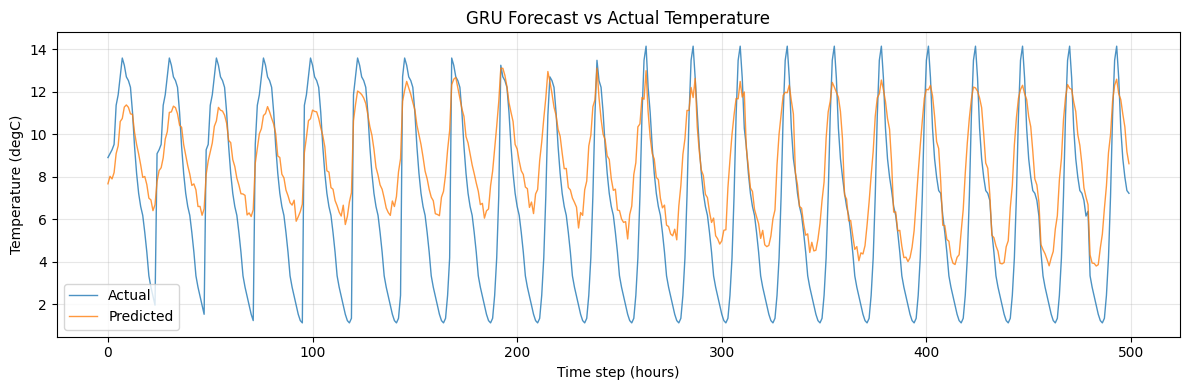

[Evaluation] Logged artifact: predictions_vs_actual.png


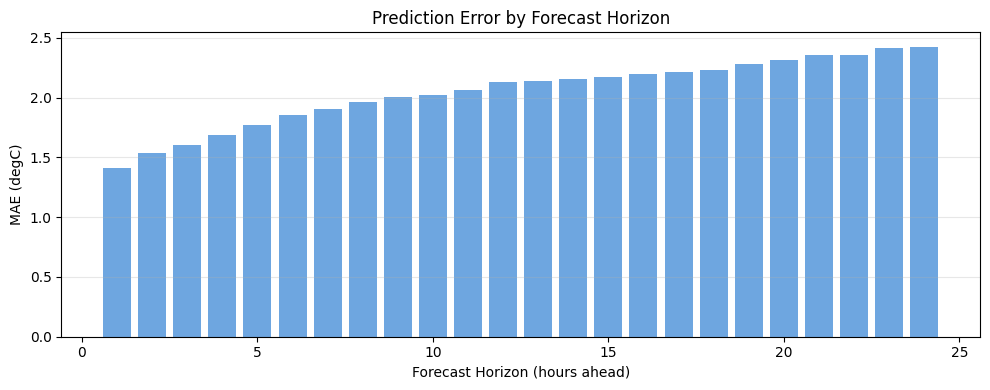

2026/03/28 04:26:59 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


[Evaluation] Logged artifact: horizon_mae.png


[Evaluation] Model logged as artifact (not registered)

Model registered: False


In [5]:
eval_result = evaluate(result, cfg)

print(f"\nModel registered: {eval_result['registered']}")
if eval_result['model_version']:
    print(f"Registry version: {eval_result['model_version']}")

## 6. Prediction Scatter Plot

Scatter plot of predicted vs actual temperature to assess overall model accuracy.

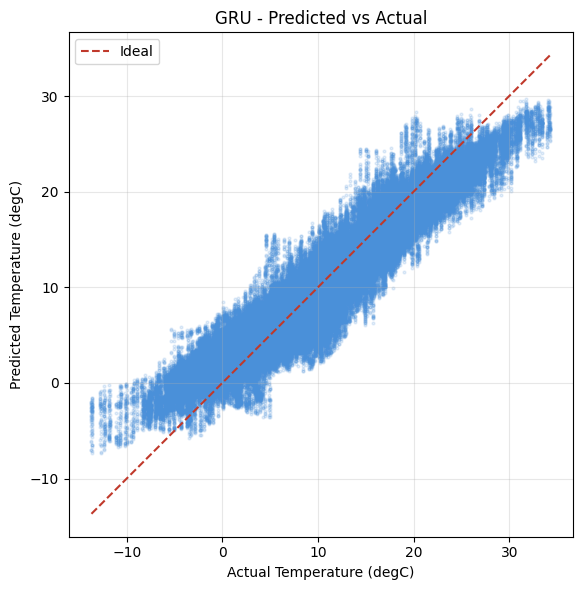

In [6]:
import matplotlib.pyplot as plt
import numpy as np

y_true = result['y_test_c'].reshape(-1)
y_pred = result['y_pred_c'].reshape(-1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true, y_pred, alpha=0.15, s=4, color='#4a90d9')

# Ideal prediction line
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, '--', color='#c0392b', linewidth=1.5, label='Ideal')

ax.set_xlabel('Actual Temperature (degC)')
ax.set_ylabel('Predicted Temperature (degC)')
ax.set_title(f'{cfg.model.type} - Predicted vs Actual')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()